# PA-23 — Identification du locuteur actif parlant à l'IA
**Sprint 3 | Équipe P07 | Projet Stellantis**

Ce notebook implémente la détection du locuteur actif via un mot-clé déclencheur ("Hey Assistant").

**Pipeline :**
1. Génération d'un audio synthétique multi-locuteurs avec gTTS + pitch-shift
2. VAD (Silero) → détection des segments de parole
3. Transcription (Whisper tiny) → détection du mot-clé
4. Diarisation (pyannote) → attribution du locuteur au moment du trigger
5. Export JSON + affichage timeline

**Prérequis :** token HuggingFace configuré dans les secrets Colab (`HF_TOKEN`).

## 1. Installation des dépendances
⚠️ Redémarrer le runtime après cette cellule.

In [3]:
!pip install -q gtts pydub openai-whisper pyannote.audio silero-vad librosa soundfile
!apt-get install -q ffmpeg
print('✅ Installation OK — redémarre le runtime !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 28.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Audio

Script simple entre Ranim et Sainte-Christe

In [8]:
from google.colab import files
from pydub import AudioSegment
import os

os.makedirs('pa23_audio', exist_ok=True)

# Upload de votre enregistrement
print("📂 Upload votre fichier audio (wav, m4a, mp3)...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Conversion en wav 16kHz mono
audio = AudioSegment.from_file(filename)
audio = audio.set_channels(1).set_frame_rate(16000)
OUTPUT_PATH = 'pa23_audio/dialogue_synth.wav'
audio.export(OUTPUT_PATH, format='wav')

duration = len(audio) / 1000
print(f'✅ Audio chargé et converti : {filename} → {OUTPUT_PATH} ({duration:.1f}s)')

# Lecture de l'audio dans le notebook
import IPython.display as ipd
print('\n🎧 Écoute de l\'audio :')
ipd.display(ipd.Audio(OUTPUT_PATH, rate=16000))

📂 Upload votre fichier audio (wav, m4a, mp3)...


Saving Télécom Saint-Étienne 2.m4a to Télécom Saint-Étienne 2.m4a
✅ Audio chargé et converti : Télécom Saint-Étienne 2.m4a → pa23_audio/dialogue_synth.wav (19.5s)

🎧 Écoute de l'audio :


## 3. Chargement des modèles
Silero VAD + pyannote diarisation + Whisper tiny

In [13]:
import torchaudio, torch, whisper
from pyannote.audio import Pipeline
from google.colab import userdata

# Patch compatibilité torchaudio / pyannote
if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

# pyannote
HF_TOKEN = userdata.get('HF_TOKEN')
pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1',
     token=HF_TOKEN
)
print('✅ pyannote chargé')

# Silero VAD
vad_model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print('✅ Silero VAD chargé')

# Whisper tiny (rapide, suffisant pour détecter un mot-clé)
whisper_model = whisper.load_model('base')
print('✅ Whisper tiny chargé')

✅ pyannote chargé
✅ Silero VAD chargé


Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master
100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 57.3MiB/s]


✅ Whisper tiny chargé


## 4. VAD — Détection des segments de parole

In [28]:
SAMPLE_RATE = 16000
AUDIO_PATH  = 'pa23_audio/dialogue_synth.wav'

waveform, sr = torchaudio.load(AUDIO_PATH)
audio_1d = waveform.squeeze(0)
duration = waveform.shape[1] / SAMPLE_RATE

speech_timestamps = get_speech_timestamps(
    audio_1d, vad_model,
    sampling_rate=SAMPLE_RATE,
    threshold=0.4,
    min_speech_duration_ms=200,
    min_silence_duration_ms=100
)

print(f'📁 Audio : {AUDIO_PATH} ({duration:.1f}s)')
print(f'🔊 VAD : {len(speech_timestamps)} segment(s) de parole détecté(s)\n')
for i, ts in enumerate(speech_timestamps):
    start_s = ts['start'] / SAMPLE_RATE
    end_s   = ts['end']   / SAMPLE_RATE
    print(f'  Segment {i+1:02d} : [{start_s:5.2f}s → {end_s:5.2f}s] ({end_s - start_s:.2f}s)')

📁 Audio : pa23_audio/dialogue_synth.wav (19.5s)
🔊 VAD : 8 segment(s) de parole détecté(s)

  Segment 01 : [ 1.31s →  3.36s] (2.04s)
  Segment 02 : [ 4.00s →  4.80s] (0.80s)
  Segment 03 : [ 4.99s →  6.40s] (1.40s)
  Segment 04 : [ 6.72s →  8.61s] (1.88s)
  Segment 05 : [ 9.35s → 10.85s] (1.50s)
  Segment 06 : [13.31s → 14.14s] (0.83s)
  Segment 07 : [14.47s → 15.61s] (1.15s)
  Segment 08 : [16.13s → 17.89s] (1.76s)


## 5. Diarisation — Attribution des locuteurs

In [29]:
diarization = pipeline(AUDIO_PATH)

diarization_segments = []
print('🎙️ Segments diarisés :\n')

annotation = diarization.speaker_diarization

for segment, track, speaker in annotation.itertracks(yield_label=True):
    seg = {
        'start':   round(segment.start, 3),
        'end':     round(segment.end,   3),
        'speaker': speaker
    }
    diarization_segments.append(seg)
    print(f'  [{seg["start"]:6.2f}s → {seg["end"]:6.2f}s]  {speaker}')

speakers_found = list(set(s['speaker'] for s in diarization_segments))
print(f'\n  ✅ {len(speakers_found)} locuteur(s) détecté(s) : {speakers_found}')


def get_speaker_at(timestamp, segments, default='UNKNOWN'):
    """Retourne le locuteur actif à un instant T (en secondes)."""
    for seg in segments:
        if seg['start'] <= timestamp <= seg['end']:
            return seg['speaker']
    return default

🎙️ Segments diarisés :

  [  1.28s →   3.25s]  SPEAKER_00
  [  3.93s →   6.36s]  SPEAKER_01
  [  6.73s →   8.47s]  SPEAKER_00
  [  9.35s →  10.76s]  SPEAKER_01
  [ 13.28s →  15.56s]  SPEAKER_01
  [ 16.13s →  17.78s]  SPEAKER_00

  ✅ 2 locuteur(s) détecté(s) : ['SPEAKER_00', 'SPEAKER_01']


## 6. Transcription Whisper + Détection du mot-clé

Whisper transcrit chaque segment VAD.  
Si "hey assistant" est détecté dans le texte → on identifie le locuteur via pyannote.

In [30]:
import soundfile as sf
import numpy as np
import json, datetime
import IPython.display as ipd

WAKE_WORD_VARIANTS = [
    'hey assistant',
    'assistant',
    'hey assistan',
    'elles assistent',
    'et assistant',
    'hé assistant',
    'assiste ton'
]

SAMPLE_RATE  = 16000
audio_array  = audio_1d.numpy()
triggers     = []

print(f'🔗 VAD : {len(speech_timestamps)} segments\n')
print(f'  {"Segment":<10} {"Durée":<10} {"Texte transcrit":<50} {"Trigger":<8} {"Locuteur"}')
print('  ' + '-' * 95)

for i, ts in enumerate(speech_timestamps):
    start_sample = ts['start']
    end_sample   = ts['end']
    start_s      = start_sample / SAMPLE_RATE
    end_s        = end_sample   / SAMPLE_RATE

    chunk = audio_array[start_sample:end_sample]
    chunk_path = f'pa23_audio/chunk_{i:02d}.wav'
    sf.write(chunk_path, chunk, SAMPLE_RATE)

    # Transcription Whisper
    result = whisper_model.transcribe(chunk_path, language='fr', fp16=False)
    text   = result['text'].strip().lower()

    is_trigger  = any(variant in text for variant in WAKE_WORD_VARIANTS)
    speaker     = get_speaker_at(start_s + (end_s - start_s) / 2, diarization_segments)
    trigger_str = '🔔 OUI' if is_trigger else '—'

    # Texte + player groupés
    print(f'\n  ── Seg {i+1:02d} [{start_s:.2f}s → {end_s:.2f}s] | "{text[:45]}" | {trigger_str} | {speaker}')
    ipd.display(ipd.Audio(chunk_path, rate=SAMPLE_RATE))

    if is_trigger:
        triggers.append({
            'segment_id':      i + 1,
            'timestamp_start': round(start_s, 3),
            'timestamp_end':   round(end_s,   3),
            'trigger_word':    next(v for v in WAKE_WORD_VARIANTS if v in text),
            'transcript':      text,
            'active_speaker':  speaker
        })

print(f'\n  ✅ {len(triggers)} déclenchement(s) détecté(s)')

🔗 VAD : 8 segments

  Segment    Durée      Texte transcrit                                    Trigger  Locuteur
  -----------------------------------------------------------------------------------------------

  ── Seg 01 [1.31s → 3.36s] | "bonjour, je suis allu le rapport de ce matin." | — | SPEAKER_00



  ── Seg 02 [4.00s → 4.80s] | "oui je l'ai dû." | — | SPEAKER_01



  ── Seg 03 [4.99s → 6.40s] | "il y a des points intéressants." | — | SPEAKER_01



  ── Seg 04 [6.72s → 8.61s] | "hey assistant, quelle est rétile ?" | 🔔 OUI | SPEAKER_00



  ── Seg 05 [9.35s → 10.85s] | "moi aussi j'ai une question pour toi." | — | SPEAKER_01



  ── Seg 06 [13.31s → 14.14s] | "elles assistent." | 🔔 OUI | SPEAKER_01



  ── Seg 07 [14.47s → 15.61s] | "quel est le temps aujourd'hui ?" | — | SPEAKER_01



  ── Seg 08 [16.13s → 17.89s] | "d'accord, on se retrouve à 14 heures alors." | — | SPEAKER_00



  ✅ 2 déclenchement(s) détecté(s)


## 7. Export JSON
Sortie structurée conforme au format P07.

In [32]:
output = {
    'metadata': {
        'story':              'PA-23',
        'audio_file':         'dialogue_synth.wav',
        'duration_s':         round(duration, 3),
        'processed_at':       datetime.datetime.now().isoformat(),
        'vad_model':          'silero-vad',
        'diarization_model':  'pyannote/speaker-diarization-3.1',
        'transcription_model':'whisper-tiny',
        'wake_word':          WAKE_WORD_VARIANTS,
        'speakers_detected':  speakers_found,
        'num_triggers':       len(triggers)
    },
    'diarization_segments': diarization_segments,
    'wake_word_triggers':   triggers
}

json_path = 'pa23_audio/pa23_output.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('📄 JSON exporté :')
print(json.dumps(output, ensure_ascii=False, indent=2))

📄 JSON exporté :
{
  "metadata": {
    "story": "PA-23",
    "audio_file": "dialogue_synth.wav",
    "duration_s": 19.476,
    "processed_at": "2026-06-02T13:25:57.315810",
    "vad_model": "silero-vad",
    "diarization_model": "pyannote/speaker-diarization-3.1",
    "transcription_model": "whisper-tiny",
    "wake_word": [
      "hey assistant",
      "assistant",
      "hey assistan",
      "elles assistent",
      "et assistant",
      "hé assistant",
      "assiste ton"
    ],
    "speakers_detected": [
      "SPEAKER_00",
      "SPEAKER_01"
    ],
    "num_triggers": 2
  },
  "diarization_segments": [
    {
      "start": 1.28,
      "end": 3.254,
      "speaker": "SPEAKER_00"
    },
    {
      "start": 3.929,
      "end": 6.359,
      "speaker": "SPEAKER_01"
    },
    {
      "start": 6.73,
      "end": 8.468,
      "speaker": "SPEAKER_00"
    },
    {
      "start": 9.346,
      "end": 10.763,
      "speaker": "SPEAKER_01"
    },
    {
      "start": 13.278,
      "end": 15.5

## 8. Visualisation — Timeline + marqueurs de déclenchement

/tmp/ipykernel_5787/1417770576.py:43: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5787/1417770576.py:46: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.savefig(img_path, dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


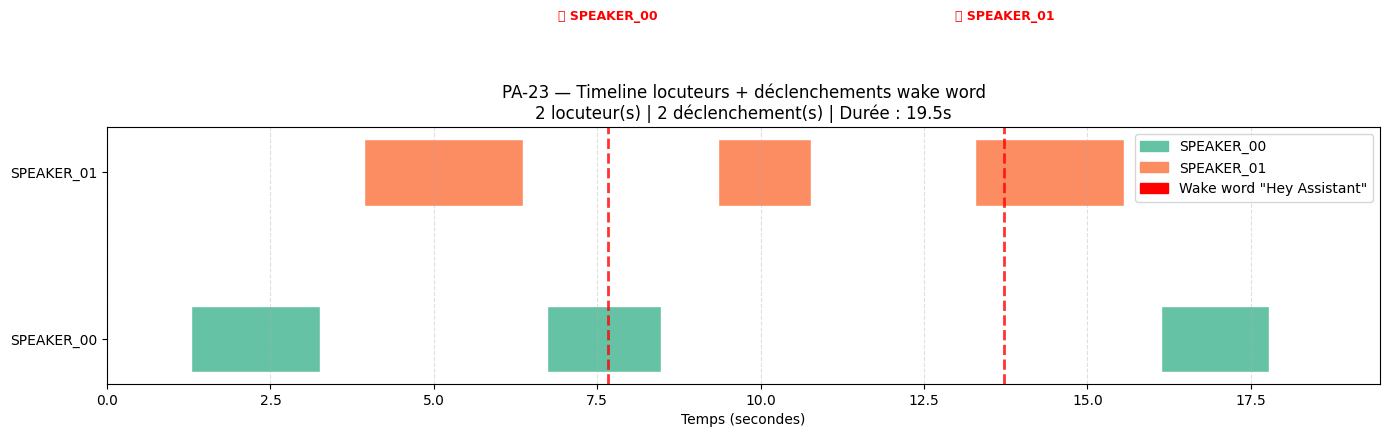

✅ Timeline sauvegardée → pa23_audio/pa23_timeline.png


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors_map = plt.cm.Set2.colors
speakers   = list(dict.fromkeys(s['speaker'] for s in diarization_segments))
spk_colors = {spk: colors_map[i % len(colors_map)] for i, spk in enumerate(speakers)}

fig, ax = plt.subplots(figsize=(14, 2 + len(speakers) * 1.5))

# Barres de diarisation
for seg in diarization_segments:
    ax.barh(
        y=seg['speaker'],
        width=seg['end'] - seg['start'],
        left=seg['start'],
        color=spk_colors[seg['speaker']],
        edgecolor='white',
        height=0.4
    )

# Marqueurs de déclenchement (lignes verticales rouges)
for t in triggers:
    mid = (t['timestamp_start'] + t['timestamp_end']) / 2
    ax.axvline(x=mid, color='red', linewidth=2, linestyle='--', alpha=0.8)
    ax.text(
        mid, len(speakers) - 0.1,
        f'🔔 {t["active_speaker"]}',
        ha='center', va='bottom', fontsize=9,
        color='red', fontweight='bold'
    )

patches = [mpatches.Patch(color=spk_colors[spk], label=spk) for spk in speakers]
patches.append(mpatches.Patch(color='red', label='Wake word "Hey Assistant"'))
ax.legend(handles=patches, loc='upper right')

ax.set_xlabel('Temps (secondes)')
ax.set_title(
    f'PA-23 — Timeline locuteurs + déclenchements wake word\n'
    f'{len(speakers)} locuteur(s) | {len(triggers)} déclenchement(s) | Durée : {duration:.1f}s'
)
ax.set_xlim(0, duration)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

img_path = 'pa23_audio/pa23_timeline.png'
plt.savefig(img_path, dpi=150)
plt.show()
print(f'✅ Timeline sauvegardée → {img_path}')

## 9. Récapitulatif PA-23

In [34]:
print('=' * 60)
print('  RÉCAPITULATIF — PA-23 Active Speaker Detection')
print('=' * 60)
print(f'  Audio          : dialogue_synth.wav ({duration:.1f}s)')
print(f'  Locuteurs      : {len(speakers_found)} détecté(s) → {speakers_found}')
print(f'  Mot-clé        : "{WAKE_WORD_VARIANTS}"')
print(f'  Déclenchements : {len(triggers)}')
print()
for t in triggers:
    print(f'  🔔 [{t["timestamp_start"]}s → {t["timestamp_end"]}s]')
    print(f'     Locuteur actif  : {t["active_speaker"]}')
    print(f'     Transcription   : "{t["transcript"]}"')
    print()
print('=' * 60)
print('  Fichiers générés dans pa23_audio/ :')
print('    - dialogue_synth.wav  (audio synthétique)')
print('    - pa23_output.json    (résultats structurés)')
print('    - pa23_timeline.png   (visualisation)')
print('=' * 60)

  RÉCAPITULATIF — PA-23 Active Speaker Detection
  Audio          : dialogue_synth.wav (19.5s)
  Locuteurs      : 2 détecté(s) → ['SPEAKER_00', 'SPEAKER_01']
  Mot-clé        : "['hey assistant', 'assistant', 'hey assistan', 'elles assistent', 'et assistant', 'hé assistant', 'assiste ton']"
  Déclenchements : 2

  🔔 [6.722s → 8.606s]
     Locuteur actif  : SPEAKER_00
     Transcription   : "hey assistant, quelle est rétile ?"

  🔔 [13.314s → 14.142s]
     Locuteur actif  : SPEAKER_01
     Transcription   : "elles assistent."

  Fichiers générés dans pa23_audio/ :
    - dialogue_synth.wav  (audio synthétique)
    - pa23_output.json    (résultats structurés)
    - pa23_timeline.png   (visualisation)
